# Hospital Patient Flow Demand Analysis
### Fourth Notebook: Nursing Workforce Planning Optimization Case Study

This fourth phase presents a hypothetical nursing workforce planning case study designed to demonstrate how operational data and optimization methods can support healthcare staffing decisions.

Building on previous analyses of hospital operational indicators, this notebook explores how nursing workforce allocation decisions can be structured as a mathematical optimization problem. The objective is to determine the optimal allocation of additional nursing staff across hospital departments while considering current workforce availability, department-level staffing requirements, outsourced labor costs, and budget limitations.

The scope of this exercise is intentionally limited to a simplified nursing workforce allocation problem. Rather than attempting to reproduce the full complexity of hospital workforce management, the case study focuses on developing a transparent decision framework based on workforce structure, cost assumptions, and operational staffing requirements.

This case study highlights that successful optimization depends not only on mathematical methods, but also on the quality of available information, the definition of realistic assumptions, and the formulation of appropriate operational constraints. Even a simple staffing decision can become a complex resource allocation problem when workforce limitations, external labor alternatives, and financial considerations are introduced.

The overall goal is to demonstrate how analytical methods can transform operational information into structured decision support for nursing workforce planning.

**Author**: J-F J  
**Date**: July 2026  
**Dataset**: Healthcare Analytics Patient Flow Data (Kaggle)

## 1-Data Loading and Overview

In [1]:
import pandas as pd
import sys
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

def load_excel_data(file_path):
    xls = pd.ExcelFile(file_path)

    sheets = [
        s for s in xls.sheet_names
        if s != "Lists"
    ]

    data = {
        sheet: pd.read_excel(xls, sheet_name=sheet)
        for sheet in sheets
    }

    overview = pd.DataFrame({
        "table_name": sheets,
        "n_rows": [data[s].shape[0] for s in sheets],
        "n_cols": [data[s].shape[1] for s in sheets]
    })

    return data, overview

# Operational datasets
dataframes, overview_operational = load_excel_data(
    "/kaggle/input/datasets/jfjutras07/hospital-operational-datasets/hospital_operational_datasets.xlsx"
)

# Forecasting datasets
dataframes2, overview_forecasting = load_excel_data(
    "/kaggle/input/datasets/jfjutras07/hospital-forecasting-datasets/hospital_forecasting_datasets.xlsx"
)

display(overview_operational)
display(overview_forecasting)

,table_name,n_rows,n_cols
0,Patient Features,9216,19
1,Daily Demand,579,2
2,Hourly Demand,24,2
3,Department Shift Demand,21,3
4,Workforce Structure,7,6
5,Workforce Costs,5,2
6,Workforce Schedule,5,5


,table_name,n_rows,n_cols
0,Model Performance,9,3
1,Demand Forecast,116,4
2,Forecast Uncertainty,4,2


In [2]:
# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3901, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 3901 (delta 252), reused 134 (delta 134), pack-reused 3591 (from 3)
Receiving objects: 100% (3901/3901), 1.30 MiB | 6.31 MiB/s, done.
Resolving deltas: 100% (2565/2565), done.


## 2-Case Study Design

Hospital management has been granted a recurring annual **clinical budget of $1,000,000** to improve nursing workforce capacity across departments.

The **objective** is to determine the optimal number of additional nurses to hire and their allocation across departments in order to **reduce outsourced labor requirements** while maintaining minimum staffing requirements under the defined operational assumptions.

The optimization model will identify the most **cost-effective nursing workforce allocation** by considering department-level staffing requirements, current nursing availability, outsourced labor costs, and the financial constraints associated with additional staffing decisions.


### Summary of the Required Information for Optimization

| Information required for optimization  | What we currently have                                                                     | What is missing / needs to be added                                                               |
| -------------------------------------- | ------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------- |
| Department-level staffing requirements | Operational indicators and department-level workforce information                           | Define staffing requirement assumptions by department                                             |
| Current nursing workforce structure   | `Workforce Structure` table with nursing staff counts by department                         | Aggregate current nursing availability by department                                              |
| Nursing workforce availability        | Workforce structure information by department                                               | Estimate available nursing hours by department based on defined scheduling assumptions            |
| Nursing workforce costs               | `Workforce Costs` table with hourly nursing cost                                             | Calculate annual internal nursing cost and integrate hiring costs into the optimization model     |
| Nursing requirement assumptions       | Not currently defined                                                                       | Define department-specific assumptions linking workforce availability to required staffing levels |
| Outsourced labor information           | Not currently defined                                                                       | Define outsourced nursing cost assumptions by department                                          |
| Hiring decisions                       | Not currently defined                                                                       | Define decision variables representing additional nurses hired by department                     |

**Load Optimization Tables**

In [3]:
# Load optimization input tables

department_shift_demand = dataframes["Department Shift Demand"].copy()
workforce_structure = dataframes["Workforce Structure"].copy()
workforce_costs = dataframes["Workforce Costs"].copy()
workforce_schedule = dataframes["Workforce Schedule"].copy()

**Current Nursing Workforce Structure**

The current workforce structure provides the number of nurses available in each clinical department. Since the optimization model focuses on department-level workforce allocation, the existing nursing workforce is used as the baseline staffing level before evaluating additional hiring decisions.

In [4]:
# Filter current workforce structure for nurses only
nursing_workforce = workforce_structure[
    [
        "Department Referral",
        "Nurses"
    ]
].copy()

display(nursing_workforce)

,Department Referral,Nurses
0,General Practice,30
1,Orthopedics,18
2,Physiotherapy,12
3,Cardiology,16
4,Neurology,14
5,Gastroenterology,10
6,Renal,8


**Nursing Workforce Availability**

The optimization model requires an estimation of available nursing hours by department. Since the model focuses on department-level workforce allocation, current nursing availability is aggregated to estimate the available staffing resources for each clinical department. The available nursing hours are calculated using the current number of nurses and the assumed shift duration.

In [5]:
# Calculate nursing availability by department
nursing_availability = nursing_workforce.copy()

# To simplify the workforce capacity representation, each nurse is modeled as providing one
# standardized operational shift of 8 hours. Overtime, absenteeism, shift variability, 
# and scheduling complexity are intentionally excluded from the model scope.
shift_duration_hours = 8

nursing_availability["Available Nursing Hours"] = (
    nursing_availability["Nurses"]
    *
    shift_duration_hours
)

display(nursing_availability)

,Department Referral,Nurses,Available Nursing Hours
0,General Practice,30,240
1,Orthopedics,18,144
2,Physiotherapy,12,96
3,Cardiology,16,128
4,Neurology,14,112
5,Gastroenterology,10,80
6,Renal,8,64


**Nursing Workforce Costs**

The optimization model requires the cost associated with additional nursing staff. The workforce cost information is used to estimate the financial impact of hiring additional nurses and integrate hiring decisions into the optimization objective function.

In [6]:
# Extract nursing hourly cost
nursing_cost = workforce_costs[
    workforce_costs["Professional Category"] == "Nurses"
].copy()

# Calculate annual internal nurse cost
annual_working_hours = 2080

nursing_cost["Annual Internal Nurse Cost"] = (
    nursing_cost["Hourly Cost"]
    *
    annual_working_hours
)

display(nursing_cost)

,Professional Category,Hourly Cost,Annual Internal Nurse Cost
2,Nurses,50,104000


**Nursing Requirement Assumptions**

The optimization model requires department-specific assumptions to estimate nursing requirements. Since each clinical department has different operational characteristics, the nursing requirement percentage is defined individually by department rather than applying a single global assumption.

In [7]:
# Define department-specific nursing requirement assumptions
nursing_requirement_assumption = pd.DataFrame({
    "Department Referral": [
        "Cardiology",
        "Gastroenterology",
        "General Practice",
        "Neurology",
        "Orthopedics",
        "Physiotherapy",
        "Renal"
    ],
    "Nursing Requirement %": [
        0.25,
        0.20,
        0.15,
        0.25,
        0.30,
        0.05,
        0.25
    ]
})

display(nursing_requirement_assumption)

,Department Referral,Nursing Requirement %
0,Cardiology,0.25
1,Gastroenterology,0.20
2,General Practice,0.15
3,Neurology,0.25
4,Orthopedics,0.30
5,Physiotherapy,0.05
6,Renal,0.25


**Outsourced Nursing Labor Information**

The optimization model considers outsourced nursing labor as an alternative solution when internal nursing resources are insufficient. Since external nursing resources may have different costs depending on department requirements, outsourced labor costs are defined by department. These costs will later be compared with the cost of hiring additional internal nurses.

In [8]:
# Define outsourced nursing labor costs by department
outsourced_nursing_cost = pd.DataFrame({
    "Department Referral": [
        "Cardiology",
        "Gastroenterology",
        "General Practice",
        "Neurology",
        "Orthopedics",
        "Physiotherapy",
        "Renal"
    ],
    "Outsourced Nurse Hourly Cost": [
        75,
        70,
        65,
        75,
        80,
        60,
        85
    ]
})

optimization_constraints = nursing_availability.merge(
    outsourced_nursing_cost,
    on="Department Referral",
    how="left"
)

optimization_constraints["Annual Outsourced Nurse Cost"] = (
    optimization_constraints["Outsourced Nurse Hourly Cost"]
    *
    annual_working_hours
)

display(
    optimization_constraints[
        [
            "Department Referral",
            "Outsourced Nurse Hourly Cost",
            "Annual Outsourced Nurse Cost"
        ]
    ]
)

,Department Referral,Outsourced Nurse Hourly Cost,Annual Outsourced Nurse Cost
0,General Practice,65,135200
1,Orthopedics,80,166400
2,Physiotherapy,60,124800
3,Cardiology,75,156000
4,Neurology,75,156000
5,Gastroenterology,70,145600
6,Renal,85,176800


**Hiring Decisions**

The optimization model must determine the number of additional nurses required to improve internal workforce availability. Hiring decisions are represented as decision variables defined by department. The model will identify the most efficient allocation of additional nursing resources while respecting staffing and financial constraints.

In [9]:
# Define hiring decision structure by department
hiring_decisions = nursing_availability[
    [
        "Department Referral"
    ]
].copy()

hiring_decisions["Additional Nurses"] = 0

display(hiring_decisions)

,Department Referral,Additional Nurses
0,General Practice,0
1,Orthopedics,0
2,Physiotherapy,0
3,Cardiology,0
4,Neurology,0
5,Gastroenterology,0
6,Renal,0


## 3-Workforce Planning Optimization Model

The optimization model combines nursing workforce availability, department-level staffing requirements, outsourced labor costs, hiring costs, and financial constraints. The objective is to determine the optimal allocation of additional nurses by department while maximizing workforce cost savings and maintaining minimum staffing requirements under the defined assumptions.

**Define Optimization Decision Variables**

The optimization model requires decision variables representing the number of additional nurses to hire in each department.

In [10]:
# Define optimization decision variables by department
departments = nursing_availability["Department Referral"].unique()

decision_variables = pd.DataFrame({
    "Department Referral": departments,
    "Decision Variable": [
        f"Hire_Nurse_{department}"
        for department in departments
    ]
})

display(decision_variables)

print(
    f"Number of decision variables: {len(decision_variables)}"
)

,Department Referral,Decision Variable
0,General Practice,Hire_Nurse_General Practice
1,Orthopedics,Hire_Nurse_Orthopedics
2,Physiotherapy,Hire_Nurse_Physiotherapy
3,Cardiology,Hire_Nurse_Cardiology
4,Neurology,Hire_Nurse_Neurology
5,Gastroenterology,Hire_Nurse_Gastroenterology
6,Renal,Hire_Nurse_Renal


Number of decision variables: 7


**Define Objective Function**

The optimization objective is to maximize workforce cost savings by prioritizing internal hiring where it reduces higher outsourced labor expenses.

In [11]:
import numpy as np

# Define objective function coefficients
annual_internal_nurse_cost = nursing_cost["Annual Internal Nurse Cost"].iloc[0]

objective = np.array([
    optimization_constraints.loc[
        optimization_constraints["Department Referral"] == department,
        "Annual Outsourced Nurse Cost"
    ].iloc[0] - annual_internal_nurse_cost
    for department in departments
])

display(
    pd.DataFrame({
        "Department Referral": departments,
        "Net Cost Impact": objective
    })
)

print(
    "Number of objective coefficients:",
    len(objective)
)

,Department Referral,Net Cost Impact
0,General Practice,31200
1,Orthopedics,62400
2,Physiotherapy,20800
3,Cardiology,52000
4,Neurology,52000
5,Gastroenterology,41600
6,Renal,72800


Number of objective coefficients: 7


**Define Nursing Capacity Requirements**

The optimization model requires department-level staffing requirements to determine the additional nursing staff needed before applying budget limitations.

In [12]:
# Add nursing requirement assumptions
optimization_constraints = optimization_constraints.merge(
    nursing_requirement_assumption,
    on="Department Referral",
    how="left"
)

# Estimate theoretical nursing requirement
optimization_constraints["Required Nurses"] = np.ceil(
    optimization_constraints["Nurses"]
    /
    (1 - optimization_constraints["Nursing Requirement %"])
)

# Define minimum acceptable staffing level (75% of required capacity)
optimization_constraints["Minimum Required Nurses"] = np.ceil(
    0.75 *
    optimization_constraints["Required Nurses"]
)

# Calculate minimum additional nurses required to reach 75% coverage
optimization_constraints["Minimum Additional Nurses Required"] = (
    optimization_constraints["Minimum Required Nurses"]
    -
    optimization_constraints["Nurses"]
).clip(lower=0)

display(
    optimization_constraints[
        [
            "Department Referral",
            "Nurses",
            "Required Nurses",
            "Minimum Required Nurses",
            "Minimum Additional Nurses Required"
        ]
    ]
)

,Department Referral,Nurses,Required Nurses,Minimum Required Nurses,Minimum Additional Nurses Required
0,General Practice,30,36.0,27.0,0.0
1,Orthopedics,18,26.0,20.0,2.0
2,Physiotherapy,12,13.0,10.0,0.0
3,Cardiology,16,22.0,17.0,1.0
4,Neurology,14,19.0,15.0,1.0
5,Gastroenterology,10,13.0,10.0,0.0
6,Renal,8,11.0,9.0,1.0


**Current Outsourced Nursing Labor**

The optimization model considers outsourced nursing labor as an alternative staffing option when internal nursing resources are insufficient. Outsourced nursing costs are estimated by department and will be incorporated into the optimization model to evaluate the trade-off between hiring additional internal nurses and maintaining external workforce resources.

In [13]:
# Verify outsourced nursing labor information
display(
    optimization_constraints[
        [
            "Department Referral",
            "Outsourced Nurse Hourly Cost",
            "Annual Outsourced Nurse Cost"
        ]
    ]
)

,Department Referral,Outsourced Nurse Hourly Cost,Annual Outsourced Nurse Cost
0,General Practice,65,135200
1,Orthopedics,80,166400
2,Physiotherapy,60,124800
3,Cardiology,75,156000
4,Neurology,75,156000
5,Gastroenterology,70,145600
6,Renal,85,176800


**Define Optimization Constraints**

The optimization model requires linear constraints to ensure that nursing staffing levels remain aligned with defined operational requirements and financial limitations. The constraints define minimum staffing requirements, maximum hiring limits, and budget restrictions.

In [14]:
# Define optimization constraints
constraints_matrix = []
constraints_values = []

# Minimum staffing coverage constraint (minimum 75% coverage requirement)
for _, row in optimization_constraints.iterrows():

    constraint = np.zeros(len(departments))
    department_index = list(departments).index(row["Department Referral"])

    # -Hire <= -Minimum Additional Nurses Required
    constraint[department_index] = -1

    constraints_matrix.append(constraint)

    minimum_hiring_required = (
        row["Minimum Additional Nurses Required"]
    )

    constraints_values.append(
        -minimum_hiring_required
    )

# Maximum staffing constraint (do not exceed theoretical requirement)
for _, row in optimization_constraints.iterrows():

    constraint = np.zeros(len(departments))
    department_index = list(departments).index(row["Department Referral"])

    # Hire <= Required Nurses - Current Nurses
    constraint[department_index] = 1

    constraints_matrix.append(constraint)

    maximum_hiring_allowed = (
        row["Required Nurses"]
        -
        row["Nurses"]
    )

    constraints_values.append(
        maximum_hiring_allowed
    )

# Budget constraint
budget_constraint = np.full(
    len(departments),
    annual_internal_nurse_cost
)

constraints_matrix.append(
    budget_constraint
)

constraints_values.append(
    1000000
)

constraints_matrix = np.array(constraints_matrix)
constraints_values = np.array(constraints_values)

display(
    pd.DataFrame(
        constraints_matrix,
        columns=departments
    )
)

print(
    "Number of constraints:",
    len(constraints_values)
)

,General Practice,Orthopedics,Physiotherapy,Cardiology,Neurology,Gastroenterology,Renal
0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Number of constraints: 15


**Define Optimization Integrality and Bounds**

The optimization model requires integer decision variables because nursing hiring decisions represent discrete workforce allocations. Bounds are defined to restrict the solution to feasible non-negative staffing decisions.

In [15]:
from scipy.optimize import Bounds

# Define integer decision variables
integrality = np.ones(
    len(departments),
    dtype=int
)

# Define variable bounds
bounds = Bounds(
    np.zeros(len(departments)),
    np.full(len(departments), np.inf)
)

display(
    pd.DataFrame({
        "Department Referral": departments,
        "Integrality": integrality
    })
)

,Department Referral,Integrality
0,General Practice,1
1,Orthopedics,1
2,Physiotherapy,1
3,Cardiology,1
4,Neurology,1
5,Gastroenterology,1
6,Renal,1


**Solve Workforce Planning Optimization Model**

The mixed integer programming model is solved using the previously defined objective function, constraints, integrality settings, and variable bounds. The solution identifies the optimal allocation of additional nursing staff under the defined staffing requirements and budget constraints.

In [16]:
from optimization.mixed_integer_programming import mixed_integer_programming

# Solve optimization model
solution = mixed_integer_programming(
    objective=objective,
    constraints_matrix=constraints_matrix,
    constraints_values=constraints_values,
    integrality=integrality,
    bounds=bounds,
    maximize=True
)

solution

--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 572000.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------


{'success': True,
 'status': 'Optimization terminated successfully. (HiGHS Status 7: Optimal)',
 'optimal_values': array([0., 4., 0., 1., 1., 0., 3.]),
 'objective_value': 572000.0}

The optimization model identifies the most cost-effective allocation of nine additional nurses while respecting operational coverage requirements. The solution ensures that each department remains between 75% and 100% of its estimated nursing requirement. Additional workforce capacity is allocated only where it improves internal staffing coverage and provides economic benefits by reducing reliance on outsourced nursing labor.

In [17]:
# Final optimization results table
final_optimization_results = optimization_constraints.copy()

final_optimization_results["Optimal Additional Nurses"] = solution["optimal_values"]

final_optimization_results["Final Nurses"] = (
    final_optimization_results["Nurses"]
    +
    final_optimization_results["Optimal Additional Nurses"]
)

final_optimization_results["Achieved Coverage %"] = (
    final_optimization_results["Final Nurses"]
    /
    final_optimization_results["Required Nurses"]
    *
    100
)

final_optimization_results["Minimum Coverage Requirement %"] = 75

final_optimization_results["Annual Cost Saving"] = (
    final_optimization_results["Optimal Additional Nurses"]
    *
    (
        final_optimization_results["Annual Outsourced Nurse Cost"]
        -
        annual_internal_nurse_cost
    )
)

final_optimization_results["Constraint Satisfied"] = (
    (final_optimization_results["Achieved Coverage %"] >= 75)
    &
    (final_optimization_results["Achieved Coverage %"] <= 100)
)

display(
    final_optimization_results[
        [
            "Department Referral",
            "Nurses",
            "Required Nurses",
            "Optimal Additional Nurses",
            "Final Nurses",
            "Achieved Coverage %",
            "Minimum Coverage Requirement %",
            "Annual Cost Saving",
            "Constraint Satisfied"
        ]
    ]
)

print(
    "Total Annual Cost Saving:",
    f"${final_optimization_results['Annual Cost Saving'].sum():,.0f}"
)

,Department Referral,Nurses,Required Nurses,Optimal Additional Nurses,Final Nurses,Achieved Coverage %,Minimum Coverage Requirement %,Annual Cost Saving,Constraint Satisfied
0,General Practice,30,36.0,0.0,30.0,83.333333,75,0.0,True
1,Orthopedics,18,26.0,4.0,22.0,84.615385,75,249600.0,True
2,Physiotherapy,12,13.0,0.0,12.0,92.307692,75,0.0,True
3,Cardiology,16,22.0,1.0,17.0,77.272727,75,52000.0,True
4,Neurology,14,19.0,1.0,15.0,78.947368,75,52000.0,True
5,Gastroenterology,10,13.0,0.0,10.0,76.923077,75,0.0,True
6,Renal,8,11.0,3.0,11.0,100.000000,75,218400.0,True


Total Annual Cost Saving: $572,000


## 4-Workforce Planning Uncertainty Analysis

This section evaluates the robustness of the nursing workforce optimization model under uncertainty and variations in key operational and financial assumptions. Since workforce planning decisions depend on estimated demand, staffing requirements, resource costs, and budget limitations, multiple sensitivity analyses are performed to assess the stability of the optimal solution.

For demonstration purposes, the Monte Carlo demand simulation and the optimization model are treated as separate analytical layers; the stochastic demand scenarios are used to illustrate operational uncertainty rather than being directly integrated as stochastic constraints into the MIP solver.

**Historical Daily Demand Variability Analysis**

Historical patient demand variability is analyzed to quantify operational uncertainty affecting future nursing capacity requirements. Demand fluctuations provide context for evaluating workforce planning risks.

In [18]:
# Historical Daily Demand Variability Analysis
daily_demand = dataframes["Daily Demand"].copy()

# Inspect structure
display(daily_demand.head())
display(daily_demand.columns)

,Admission Date,Patient Volume
0,2023-04-01,19
1,2023-04-02,13
2,2023-04-03,14
3,2023-04-04,9
4,2023-04-05,19


Index(['Admission Date', 'Patient Volume'], dtype='object')

**Monte Carlo Daily Demand Uncertainty Simulation**

A Monte Carlo simulation is performed to model possible variations in future patient demand based on historical demand patterns. The objective is to estimate the range of potential demand scenarios and evaluate operational uncertainty.

In [19]:
# Calculate historical demand statistics
daily_demand_uncertainty = pd.DataFrame({
    "Mean Daily Demand": [
        daily_demand["Patient Volume"].mean()
    ],
    "Std Dev Daily Demand": [
        daily_demand["Patient Volume"].std()
    ],
    "Minimum Demand": [
        daily_demand["Patient Volume"].min()
    ],
    "Maximum Demand": [
        daily_demand["Patient Volume"].max()
    ],
    "P5 Demand": [
        daily_demand["Patient Volume"].quantile(0.05)
    ],
    "P95 Demand": [
        daily_demand["Patient Volume"].quantile(0.95)
    ]
})

daily_demand_uncertainty["Demand Variability %"] = (
    daily_demand_uncertainty["Std Dev Daily Demand"]
    /
    daily_demand_uncertainty["Mean Daily Demand"]
    *
    100
)

display(daily_demand_uncertainty)

,Mean Daily Demand,Std Dev Daily Demand,Minimum Demand,Maximum Demand,P5 Demand,P95 Demand,Demand Variability %
0,15.917098,3.726836,7,30,10.0,22.0,23.414044


--- Monte Carlo Simulation Summary ---
Number of simulations : 10000

Result statistics:
Mean       15.909138
Median     15.907427
Std_Dev     3.739740
Minimum     1.298955
Maximum    30.549544
P5          9.749713
P25        13.410464
P75        18.418107
P95        22.039203
dtype: float64

--- Sensitivity Analysis ---
demand_variation    1.000000
Simulation         -0.009887
Name: Result, dtype: float64
----------------------------------------


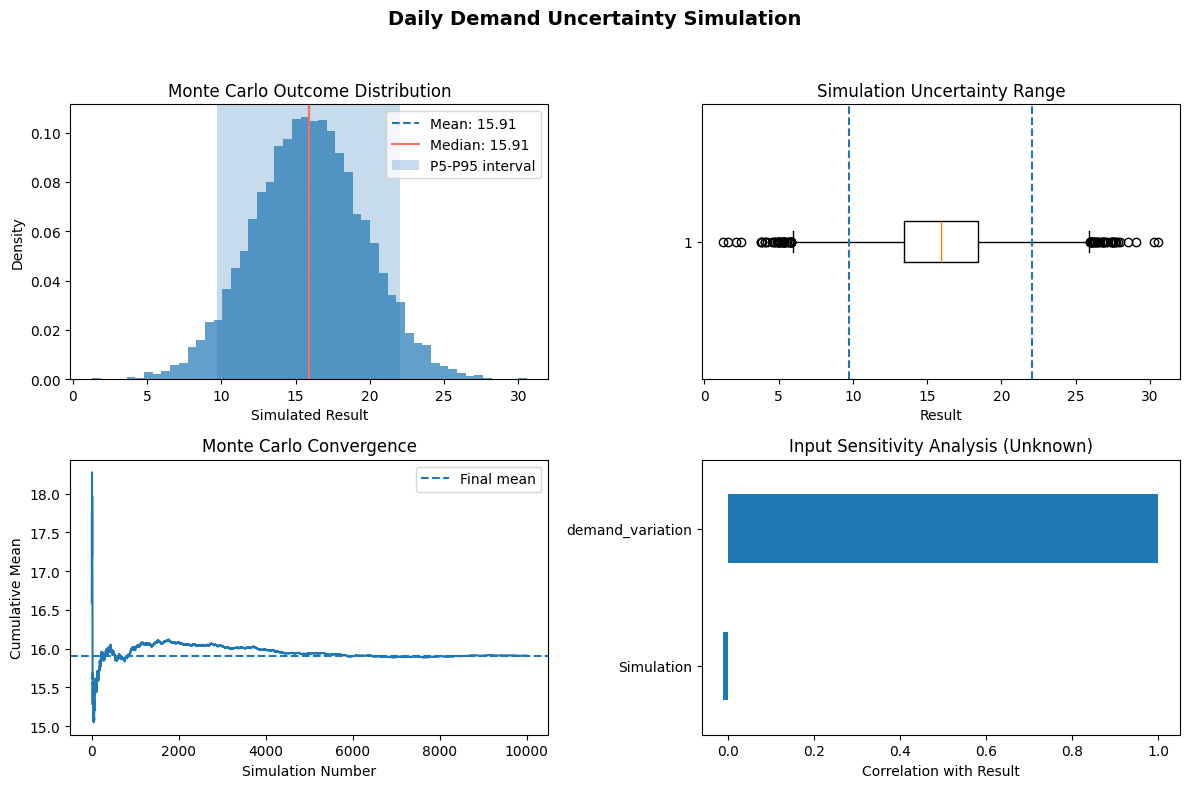

In [20]:
from optimization.monte_carlo_analysis import monte_carlo_simulation
from visualization.explore_uncertainty import plot_monte_carlo

# Monte Carlo Daily Demand Uncertainty Simulation
# Historical demand parameters
mean_daily_demand = daily_demand["Patient Volume"].mean()

demand_variability = (
    daily_demand["Patient Volume"].std()
    /
    daily_demand["Patient Volume"].mean()
)

# Model function
def daily_demand_model(demand_variation):

    return (
        mean_daily_demand
        *
        demand_variation
    )

# Define uncertainty distribution
distributions = {
    "demand_variation": lambda: np.random.normal(
        loc=1,
        scale=demand_variability
    )
}

# Run Monte Carlo
mc_demand_results = monte_carlo_simulation(
    model_function=daily_demand_model,
    distributions=distributions,
    n_simulations=10000
)

plot_monte_carlo(
    mc_demand_results,
    title="Daily Demand Uncertainty Simulation"
);

**Baseline Optimization Scenario**

The original optimization solution is used as the reference scenario for sensitivity analysis. All subsequent scenarios are compared against the baseline workforce allocation and cost saving.

In [21]:
# Store baseline optimization results
baseline_results = pd.DataFrame({
    "Department Referral": departments,
    "Baseline Additional Nurses": solution["optimal_values"]
})

display(baseline_results)

print(
    "Baseline Annual Cost Saving:",
    f"${solution['objective_value']:,.0f}"
)

,Department Referral,Baseline Additional Nurses
0,General Practice,0.0
1,Orthopedics,4.0
2,Physiotherapy,0.0
3,Cardiology,1.0
4,Neurology,1.0
5,Gastroenterology,0.0
6,Renal,3.0


Baseline Annual Cost Saving: $572,000


**Budget Constraint Sensitivity Analysis**

The annual workforce budget represents a key financial constraint in nursing workforce planning. Different budget scenarios are evaluated to determine whether financial limitations influence the optimal hiring allocation and expected cost savings.

In [22]:
# Budget Constraint Sensitivity Analysis
budget_scenarios = [
    750000,
    1000000,
    1250000,
    1500000
]

budget_results = []

for budget in budget_scenarios:

    scenario_constraints = constraints_values.copy()

    # Update budget constraint
    scenario_constraints[-1] = budget

    scenario_solution = mixed_integer_programming(
        objective=objective,
        constraints_matrix=constraints_matrix,
        constraints_values=scenario_constraints,
        integrality=integrality,
        bounds=bounds,
        maximize=True
    )

    budget_results.append({
        "Annual Budget": budget,
        "Cost Saving": scenario_solution["objective_value"],
        "Additional Nurses": scenario_solution["optimal_values"].sum(),
        "Total Hiring Cost": (
            scenario_solution["optimal_values"].sum()
            *
            annual_internal_nurse_cost
        )
    })


budget_sensitivity = pd.DataFrame(budget_results)

display(budget_sensitivity)

--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 447200.0000
Optimal variables       : [0. 2. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 572000.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 759200.0000
Optimal variables       : [0. 7. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 873600.0000
Optimal variables       : [0. 8. 0. 1. 2. 0. 3.]
---------------------------------------------


,Annual Budget,Cost Saving,Additional Nurses,Total Hiring Cost
0,750000,447200.0,7.0,728000.0
1,1000000,572000.0,9.0,936000.0
2,1250000,759200.0,12.0,1248000.0
3,1500000,873600.0,14.0,1456000.0


**Nursing Requirement Sensitivity Analysis**

Nursing requirement assumptions directly influence the workforce gap identified by the optimization model. This analysis evaluates how changes in minimum staffing requirements affect the optimal hiring allocation and expected cost savings.

In [23]:
# Nursing Requirement Sensitivity Analysis
coverage_scenarios = [
    0.70,
    0.75,
    0.80
]

coverage_results = []

for coverage in coverage_scenarios:

    scenario_constraints_matrix = []
    scenario_constraints_values = []

    # Minimum staffing constraints
    for _, row in optimization_constraints.iterrows():

        constraint = np.zeros(len(departments))
        department_index = list(departments).index(
            row["Department Referral"]
        )

        constraint[department_index] = -1

        scenario_constraints_matrix.append(constraint)

        required_nurses = np.ceil(
            row["Required Nurses"] * coverage
        )

        minimum_additional = max(
            required_nurses - row["Nurses"],
            0
        )

        scenario_constraints_values.append(
            -minimum_additional
        )

    # Maximum staffing constraints
    for _, row in optimization_constraints.iterrows():

        constraint = np.zeros(len(departments))
        department_index = list(departments).index(
            row["Department Referral"]
        )

        constraint[department_index] = 1

        scenario_constraints_matrix.append(constraint)

        scenario_constraints_values.append(
            row["Required Nurses"] - row["Nurses"]
        )

    # Budget constraint
    scenario_constraints_matrix.append(
        np.full(len(departments), annual_internal_nurse_cost)
    )

    scenario_constraints_values.append(
        1000000
    )

    scenario_solution = mixed_integer_programming(
        objective=objective,
        constraints_matrix=np.array(scenario_constraints_matrix),
        constraints_values=np.array(scenario_constraints_values),
        integrality=integrality,
        bounds=bounds,
        maximize=True
    )

    coverage_results.append({
        "Minimum Coverage Requirement": f"{coverage*100:.0f}%",
        "Cost Saving": scenario_solution["objective_value"],
        "Additional Nurses": scenario_solution["optimal_values"].sum()
    })


coverage_sensitivity = pd.DataFrame(coverage_results)

display(coverage_sensitivity)

--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 592800.0000
Optimal variables       : [0. 6. 0. 0. 0. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 572000.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 509600.0000
Optimal variables       : [0. 3. 0. 2. 2. 1. 1.]
---------------------------------------------


,Minimum Coverage Requirement,Cost Saving,Additional Nurses
0,70%,592800.0,9.0
1,75%,572000.0,9.0
2,80%,509600.0,9.0


The nursing requirement sensitivity analysis shows that higher coverage targets do not necessarily increase the number of hired nurses when budget constraints remain binding. Instead, the optimization model reallocates available workforce capacity across departments, resulting in lower cost savings as operational coverage requirements become more restrictive.

**Outsourced Nursing Cost Sensitivity Analysis**

Outsourced nursing costs directly influence the economic advantage of internal hiring. This analysis evaluates how variations in external labor costs affect the optimal workforce allocation and expected cost savings.

In [24]:
# Outsourced Nursing Cost Sensitivity Analysis
outsourced_cost_scenarios = [
    0.80,
    1.00,
    1.20
]

outsourced_cost_results = []

for cost_factor in outsourced_cost_scenarios:

    # Adjust outsourced nursing costs
    scenario_objective = np.array([
        optimization_constraints.loc[
            optimization_constraints["Department Referral"] == department,
            "Annual Outsourced Nurse Cost"
        ].iloc[0] * cost_factor
        -
        annual_internal_nurse_cost
        for department in departments
    ])

    scenario_solution = mixed_integer_programming(
        objective=scenario_objective,
        constraints_matrix=constraints_matrix,
        constraints_values=constraints_values,
        integrality=integrality,
        bounds=bounds,
        maximize=True
    )

    outsourced_cost_results.append({
        "Outsourced Cost Variation": f"{int(cost_factor*100-100):+d}%",
        "Cost Saving": scenario_solution["objective_value"],
        "Additional Nurses": scenario_solution["optimal_values"].sum()
    })

outsourced_cost_sensitivity = pd.DataFrame(
    outsourced_cost_results
)

display(outsourced_cost_sensitivity)

--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 270400.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 572000.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------
--- Mixed Integer Programming Summary ---
Optimization successful : True
Objective value         : 873600.0000
Optimal variables       : [0. 4. 0. 1. 1. 0. 3.]
---------------------------------------------


,Outsourced Cost Variation,Cost Saving,Additional Nurses
0,-20%,270400.0,9.0
1,+0%,572000.0,9.0
2,+20%,873600.0,9.0


The outsourced nursing cost sensitivity analysis shows that variations in external labor costs primarily affect the financial value of the optimal solution rather than the hiring decision itself. Under the defined staffing and budget constraints, the optimal workforce allocation remains unchanged, while higher outsourced labor costs substantially increase the economic benefits of internal hiring.

## 5-Summary - Notebook 4

| Element                                    | Objective                                          | Methods / Tools                                                                    | Key Findings                                                                                                                                    | Decision Support Implications                                                                         |
| ------------------------------------------ | -------------------------------------------------- | ---------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| Case Study Design                          | Define the workforce planning optimization problem | Operational assumptions, staffing requirements, workforce structure, cost modeling | A simplified nursing workforce planning problem was formulated using staffing, budget, and outsourced labor assumptions                         | Establishes a structured analytical framework for optimization                                        |
| Workforce Optimization                     | Identify the optimal nursing allocation            | Mixed Integer Linear Programming (MILP)                                            | The optimal solution allocated 9 additional nurses while satisfying staffing and budget constraints, generating annual cost savings of $572,000 | Supports cost-effective workforce planning decisions                                                  |
| Demand Uncertainty Assessment              | Quantify operational demand variability            | Historical demand analysis and Monte Carlo simulation                              | Daily patient demand exhibited moderate variability around historical averages                                                                  | Improves understanding of operational uncertainty affecting workforce planning                        |
| Budget Sensitivity Analysis                | Evaluate the impact of financial capacity          | Scenario analysis                                                                  | Higher workforce budgets enabled additional internal hiring and increased annual cost savings                                                   | Supports budget planning and workforce investment decisions                                           |
| Nursing Requirement Sensitivity Analysis   | Assess the impact of staffing coverage assumptions | Scenario analysis                                                                  | Higher minimum coverage requirements reduced achievable cost savings while maintaining feasible staffing allocations                            | Highlights the trade-off between operational coverage and financial efficiency                        |
| Outsourced Labor Cost Sensitivity Analysis | Evaluate the impact of external labor costs        | Scenario analysis                                                                  | Variations in outsourced nursing costs affected the economic value of the optimal solution without changing the optimal hiring allocation       | Quantifies the financial sensitivity of internal hiring decisions to external labor market conditions |


## 6-Limitations

| Limitation                          | Description                                                                                                                                                                                                             | Potential Improvement                                                                                                     |
| ----------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| Simplified workforce representation | Each nurse is modeled as providing a standardized 8-hour shift. Overtime, absenteeism, vacations, skill mix, and shift scheduling complexity are intentionally excluded.                                                | Incorporate multi-shift scheduling, nurse availability calendars, and workforce rostering constraints.                    |
| Assumed staffing requirements       | Department-specific nursing requirement percentages are hypothetical assumptions created for the case study rather than empirically estimated from clinical workload data.                                              | Estimate staffing requirements using historical patient acuity, workload indicators, or regulatory staffing standards.    |
| Deterministic optimization model    | The MILP assumes fixed parameter values for demand, staffing requirements, and workforce costs during optimization.                                                                                                     | Develop a stochastic or robust optimization model that explicitly incorporates uncertainty into the optimization process. |
| Simplified cost structure           | The objective function considers only direct internal hiring costs and outsourced nursing costs. Recruitment costs, onboarding, turnover, overtime premiums, and productivity differences are excluded.                 | Extend the objective function to include a more comprehensive representation of workforce costs.                          |
| Limited operational constraints     | The model includes staffing coverage and budget constraints but does not represent operational rules such as nurse-to-patient ratios by shift, labor regulations, contractual limitations, or specialty qualifications. | Introduce additional operational and regulatory constraints to improve practical applicability.                           |
| Independent uncertainty analysis    | Monte Carlo simulation is performed separately from the optimization model and serves only to evaluate demand variability. Simulation results are not directly incorporated into optimization decisions.                | Couple simulation outputs with optimization using stochastic programming or scenario-based optimization approaches.       |
| Static planning horizon             | The optimization considers a single annual planning period and does not capture workforce dynamics over time.                                                                                                           | Formulate a multi-period optimization model including hiring, attrition, and evolving patient demand.                     |
| Hypothetical case study             | The notebook is designed as an educational decision-support demonstration rather than a validated hospital implementation. Model assumptions and results should therefore be interpreted within this context.           | Validate the framework using real hospital staffing data and stakeholder input.                                           |
